In [808]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# import csv data file into pandas dataframe for processing the data cleaning

In [809]:
df = pd.read_csv("airbnb_data.csv")

In [810]:
df.head(1)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0


In [811]:
print("Shape of Matrix:", df.shape)
print('--'*50)
print(df.columns)

Shape of Matrix: (74111, 29)
----------------------------------------------------------------------------------------------------
Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')


# Removing useless columns that is useless for linear regression

In [812]:
cols_to_drop = ['id','name','thumbnail_url','description']
df = df.drop(columns=cols_to_drop)
df.head(1)

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,...,instant_bookable,last_review,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,...,f,18-07-2016,40.696524,-73.991617,Brooklyn Heights,2,100.0,11201,1.0,1.0


# Removing useless special characters from amenities column and couting the amenties_counts 

In [813]:
df['amenities'] = df['amenities'].apply(lambda x: x.replace("{","").replace("}","").replace('"','').split(","))
df['amenities'] = df['amenities'].apply(lambda x: [a.strip() for a in x if "translation missing" not in a])
df['amenities_count'] = df['amenities'].apply(len)
df.drop(columns=['amenities'], inplace=True)

# Checking nulls

In [814]:
df.isnull().sum().sort_values(ascending=False)

host_response_rate        18299
review_scores_rating      16722
first_review              15864
last_review               15827
neighbourhood              6872
zipcode                     968
bathrooms                   200
host_has_profile_pic        188
host_identity_verified      188
host_since                  188
beds                        131
bedrooms                     91
bed_type                      0
accommodates                  0
room_type                     0
property_type                 0
log_price                     0
city                          0
cleaning_fee                  0
cancellation_policy           0
instant_bookable              0
latitude                      0
longitude                     0
number_of_reviews             0
amenities_count               0
dtype: int64

# Checking types of unique values in columns having null values 

In [816]:
numeric_cols = ['host_response_rate','review_scores_rating','first_review','last_review', 'bathrooms',
                'host_identity_verified','host_since','host_has_profile_pic','beds','bedrooms','zipcode']

for col in numeric_cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()}")
    print("Unique Values:", df[col].unique()[:50])
    print("-" * 80)

host_response_rate | Type: object | Nulls: 18299 | Filled: 55812
Unique Values: [nan '100%' '71%' '68%' '67%' '83%' '50%' '90%' '86%' '92%' '82%' '80%'
 '89%' '93%' '99%' '0%' '88%' '96%' '70%' '94%' '91%' '25%' '95%' '98%'
 '62%' '29%' '33%' '81%' '63%' '38%' '60%' '79%' '78%' '75%' '65%' '97%'
 '87%' '40%' '54%' '53%' '58%' '76%' '30%' '64%' '17%' '20%' '77%' '73%'
 '41%' '59%']
--------------------------------------------------------------------------------
review_scores_rating | Type: float64 | Nulls: 16722 | Filled: 57389
Unique Values: [100.  93.  92.  nan  40.  97.  99.  90.  89.  91.  88.  86.  72.  98.
  95.  96.  84.  80.  94.  87.  85.  70.  60.  75.  20.  76.  83.  82.
  78.  73.  55.  81.  67.  71.  77.  79.  47.  74.  68.  66.  63.  50.
  53.  65.  64.  27.  69.  30.  58.  35.]
--------------------------------------------------------------------------------
first_review | Type: object | Nulls: 15864 | Filled: 58247
Unique Values: ['18-06-2016' '05-08-2017' '30-04-2017' na

# Handling null values

### Replacing string(num%) host_response_rate column to numeric num and replace null value with median

In [817]:
# Function to replace '%' to none and empty values replace by nan
def convert_percent(x):
    try:
        return float(str(x).replace('%',''))
    except:
        return np.nan
df['host_response_rate'] = df['host_response_rate'].apply(convert_percent)

#Calculate and Replace mull values with median
median_response = df['host_response_rate'].median()
df['host_response_rate'] = df['host_response_rate'].fillna(median_response)

### Numeric columns fills missing with median
### median because it's robust to outliers

In [818]:
numeric_cols = ['bathrooms', 'review_scores_rating', 'bedrooms', 'beds']
for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

### Converting bool categorical data to 0/1 and replace null with mode

In [819]:
# Convert t/f to 1/0 and 
df['host_has_profile_pic'] = df['host_has_profile_pic'].map({'t':1,'f':0})
df['host_identity_verified'] = df['host_identity_verified'].map({'t':1,'f':0})
# Replaces with mode
df['host_has_profile_pic'] = df['host_has_profile_pic'].fillna(df['host_has_profile_pic'].mode()[0])
df['host_identity_verified'] = df['host_identity_verified'].fillna(df['host_identity_verified'].mode()[0])

# Replace null with unknown in Text column for neigbours

In [820]:
df['neighbourhood'] = df['neighbourhood'].fillna('Unknown').str.strip()

# Feature Engineering for date columns: converting to number of days since today

In [821]:
# Converts Date columns from object to datetime DataType
df['first_review'] = pd.to_datetime(df['first_review'], dayfirst=True, errors='coerce')
df['last_review'] = pd.to_datetime(df['last_review'], dayfirst=True, errors='coerce')
df['host_since'] = pd.to_datetime(df['host_since'], dayfirst=True, errors='coerce')

# Fill missing date values with median 
df['first_review'] = df['first_review'].fillna(df['first_review'].median())
df['last_review'] = df['last_review'].fillna(df['last_review'].median())
df['host_since'] = df['host_since'].fillna(df['host_since'].median())

today = pd.Timestamp('today')

# Convert date columns into numeric features
df['host_days_since'] = (today - df['host_since']).dt.days
df['days_since_first_review'] = (today - df['first_review']).dt.days
df['days_since_last_review'] = (today - df['last_review']).dt.days

# Dropping the original date columns
df.drop(['first_review', 'last_review', 'host_since'], axis=1, inplace=True)

# Using regex we identify valid zipcode contains 4 or 5 num and remove extra string values from it 

In [822]:
import re

def clean_zipcode(x):
    x = str(x).strip()
    x = re.sub(r'\s+', '', x)
    match = re.findall(r'\d{4,5}', x)
    if match:
        return match[0]
    else:
        return 0  # replace invalid with 0

df['zipcode'] = df['zipcode'].apply(clean_zipcode).astype(int)

In [823]:
# Fill missing date values with mode in zipcode 
df['zipcode'] = df['zipcode'].fillna(df['zipcode'].mode()[0])
print(df['zipcode'].nunique())

650


In [824]:
df.isnull().sum()

log_price                  0
property_type              0
room_type                  0
accommodates               0
bathrooms                  0
bed_type                   0
cancellation_policy        0
cleaning_fee               0
city                       0
host_has_profile_pic       0
host_identity_verified     0
host_response_rate         0
instant_bookable           0
latitude                   0
longitude                  0
neighbourhood              0
number_of_reviews          0
review_scores_rating       0
zipcode                    0
bedrooms                   0
beds                       0
amenities_count            0
host_days_since            0
days_since_first_review    0
days_since_last_review     0
dtype: int64

In [825]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   log_price                74111 non-null  float64
 1   property_type            74111 non-null  object 
 2   room_type                74111 non-null  object 
 3   accommodates             74111 non-null  int64  
 4   bathrooms                74111 non-null  float64
 5   bed_type                 74111 non-null  object 
 6   cancellation_policy      74111 non-null  object 
 7   cleaning_fee             74111 non-null  bool   
 8   city                     74111 non-null  object 
 9   host_has_profile_pic     74111 non-null  float64
 10  host_identity_verified   74111 non-null  float64
 11  host_response_rate       74111 non-null  float64
 12  instant_bookable         74111 non-null  object 
 13  latitude                 74111 non-null  float64
 14  longitude             

# Select Only numeric Columns for outliers detection

In [826]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(numeric_cols)

Index(['log_price', 'accommodates', 'bathrooms', 'host_has_profile_pic',
       'host_identity_verified', 'host_response_rate', 'latitude', 'longitude',
       'number_of_reviews', 'review_scores_rating', 'zipcode', 'bedrooms',
       'beds', 'amenities_count', 'host_days_since', 'days_since_first_review',
       'days_since_last_review'],
      dtype='object')


## Outliers detection for numeric columns

In [827]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    
    percent_outliers = (len(outliers) / len(df[col])) * 100
    
    print(f"{col:<25} : {percent_outliers:6.2f}% outliers")

log_price                 :   2.07% outliers
accommodates              :   4.86% outliers
bathrooms                 :  21.34% outliers
host_has_profile_pic      :   0.30% outliers
host_identity_verified    :   0.00% outliers
host_response_rate        :  16.94% outliers
latitude                  :   0.00% outliers
longitude                 :   0.00% outliers
number_of_reviews         :  11.07% outliers
review_scores_rating      :   6.24% outliers
zipcode                   :   0.00% outliers
bedrooms                  :  32.70% outliers
beds                      :   7.67% outliers
amenities_count           :   1.84% outliers
host_days_since           :   0.25% outliers
days_since_first_review   :   7.40% outliers
days_since_last_review    :  10.84% outliers


# visualizing the data and Handling outliers

## For discrete values best we can is cap the values from right side(tail side) as shown in the distribution plot to reduce the effect of outliers 
## We cap only the top 1% extreme values using the 99th percentile only for tail part.
# That Result
## - Keeps 99% data same
## - Removes extreme highs

# Bedrooms 32.70% outliers (Right Skewed) 

Column 'bedrooms' unique values: [ 1.  3.  2.  0.  4.  5.  6.  7.  8.  9. 10.]


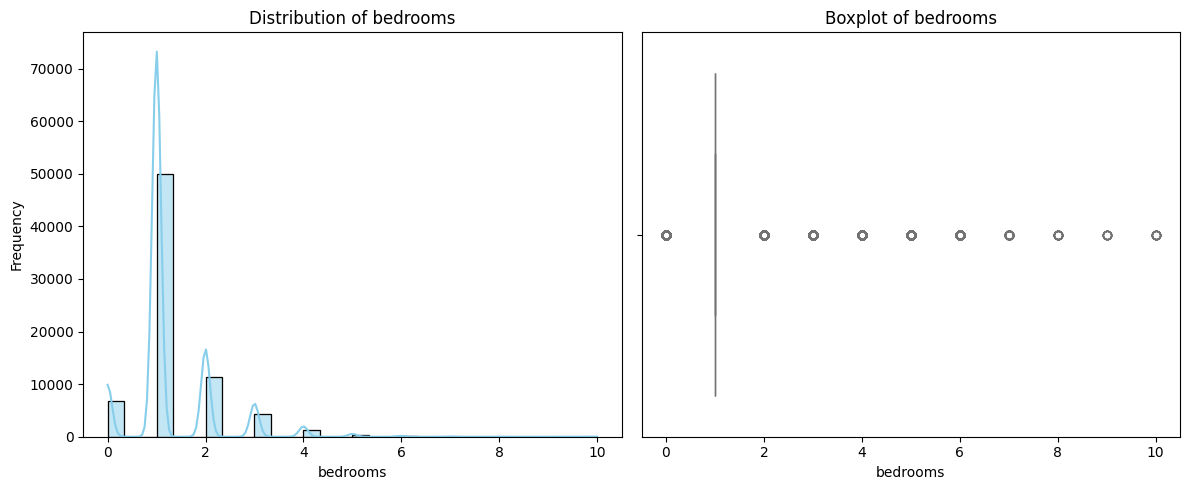

In [828]:
col = 'bedrooms'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# capping outliers only top 1% data 

In [769]:
col = 'bedrooms'
upper_limit = df[col].quantile(0.99)
lower_limit = df[col].quantile(0.01)

df[col + '_capped'] = np.where(df[col] > upper_limit, upper_limit,
                        np.where(df[col] < lower_limit, lower_limit, df[col]))

Column 'bedrooms_capped' unique values: [1. 3. 2. 0. 4.]


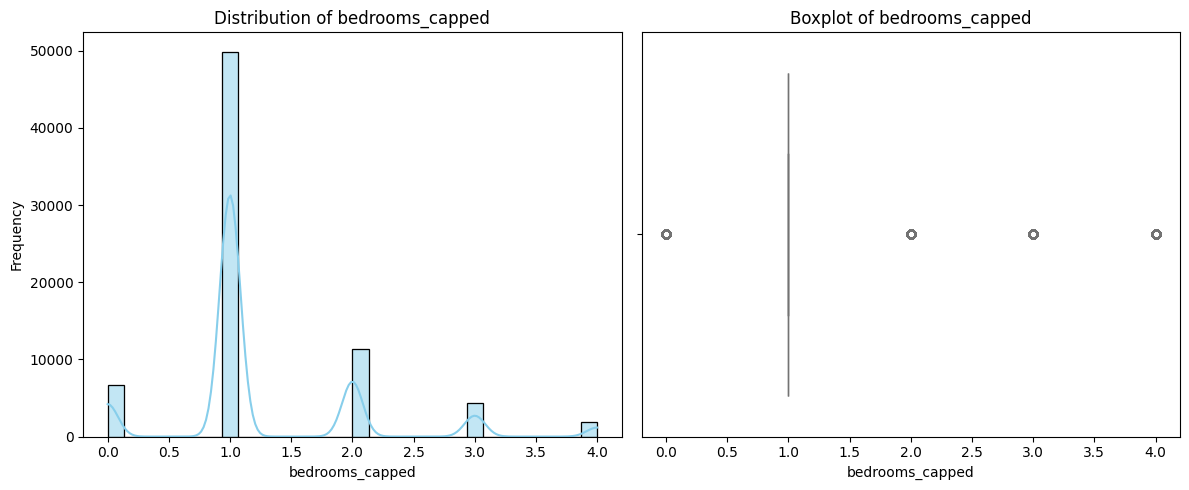

In [770]:
col = 'bedrooms_capped'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# bedrooms is discrete and skewed and very limited value, it fits better in regression if we convert it into categories and use one-hot encoding
## Drop original and capped column after use

In [771]:
df['bedrooms_cat'] = df['bedrooms_capped'].astype(str)
df = pd.get_dummies(df, columns=['bedrooms_cat'], drop_first=True)
df.drop(columns=['bedrooms_capped','bedrooms'], inplace=True)

# bathrooms 21.34% outliers (Right SKewed)

Column 'bathrooms' unique values: [1.  1.5 2.  2.5 3.  0.5 4.5 5.  0.  4.  3.5 5.5 7.5 6.  8.  7.  6.5]


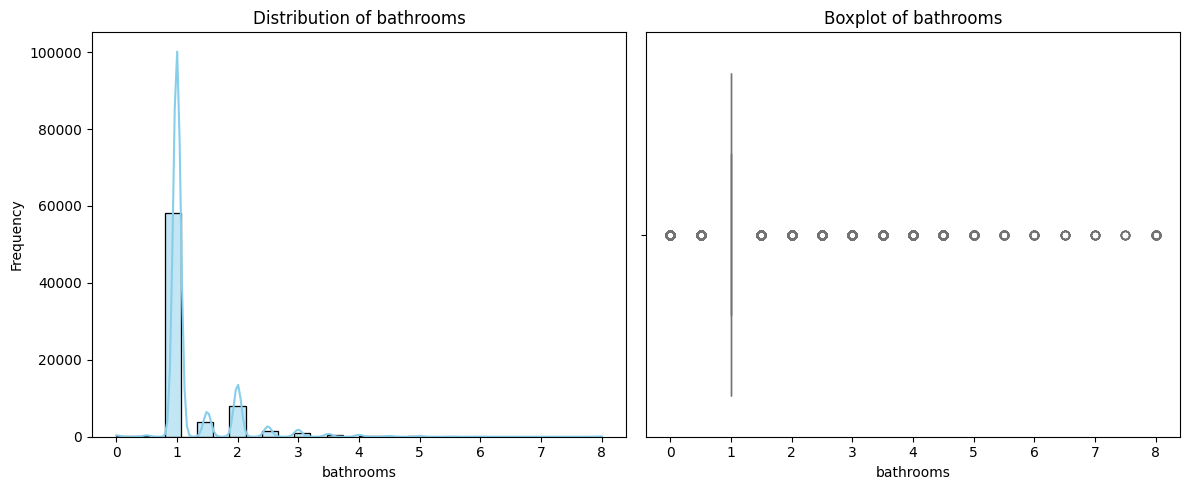

In [772]:
col = 'bathrooms'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

### Keeps 99% data same Removes extreme highs witrh 99% percentile

In [773]:
upper_limit = df['bathrooms'].quantile(0.99)
print("99th Percentile (Upper Limit):", upper_limit)

df['bathrooms_capped'] = np.where(df['bathrooms'] > upper_limit, upper_limit, df['bathrooms'])

99th Percentile (Upper Limit): 3.5


Column 'bathrooms_capped' unique values: [1.  1.5 2.  2.5 3.  0.5 3.5 0. ]


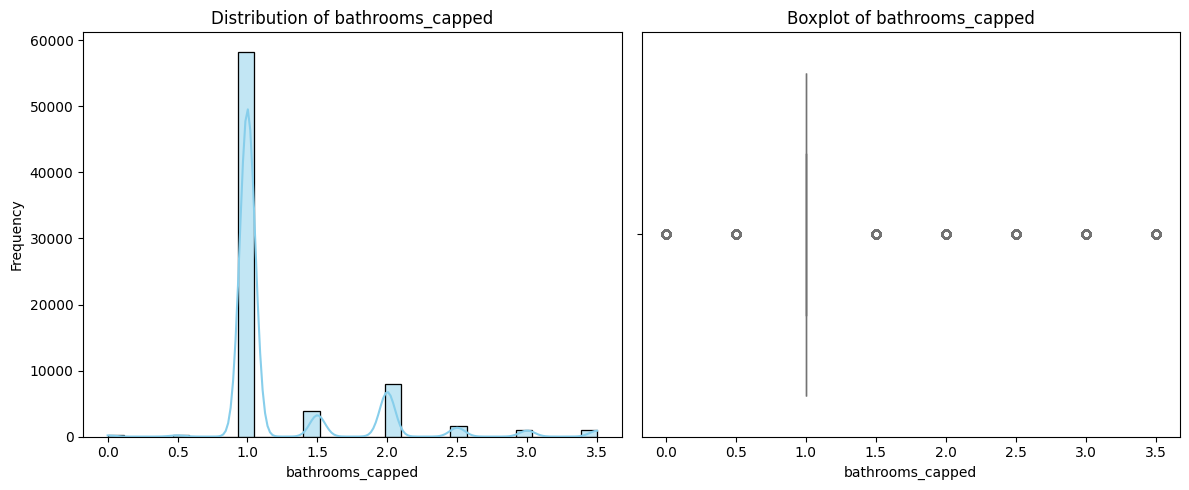

In [774]:
col = 'bathrooms_capped'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

## Also have very limited values it fits better in regression if we convert it into categories and use one-hot encoding

In [775]:
df['bathrooms_cat'] = df['bathrooms_capped'].astype(str)
df = pd.get_dummies(df, columns=['bathrooms_cat'], drop_first=True)
df.drop(columns=['bathrooms_capped', 'bathrooms'], inplace=True)

# number_of_reviews 11.07% outliers

Column 'number_of_reviews' unique values: [  2   6  10   0   4   3  15   9 159  82  29  13  12  26   5  57  73  14
   1  40 248  46  17 138  11  44  34  85  18  31  30  19  25  22  23  28
   7  32 144  16  38 105  59  67  21 120   8  61  87 206  43 104  47  63
 186  36  27 167  48 102  51 126  81  58  72  68 107  79  98  39 187 123
  70  78  55  54  52  42  75 128  60  90 254 135  64  99 191  24  66 139
 125 129  74 318  33  35  37  20  93  83  45  41  49 289 190  62  88 127
 154 118 216 136  69 314 112  77  56 181  53 117 101 106 255 114 110 192
  76 113  91 182  84 146 119  86  50  71 157  95  94 158 142  97 194 173
 122 132 171 111 161 208 131 384 133 116 134 148  89 156 179 150 147 145
 202 258 178 200 155 163 149 267 100  65 207 242 172 121 180  80  92 263
 193 251 199 103 166 237 290 137 153  96 425 185 140 168 162 360 143 214
 141 246 217 195 196 109 273 305 351 152 189 269 221 317 218 336 272 175
 215 188 278 383 169 160 203 165 115 108 130 256 198 323 465 302 469 124
 220 204 

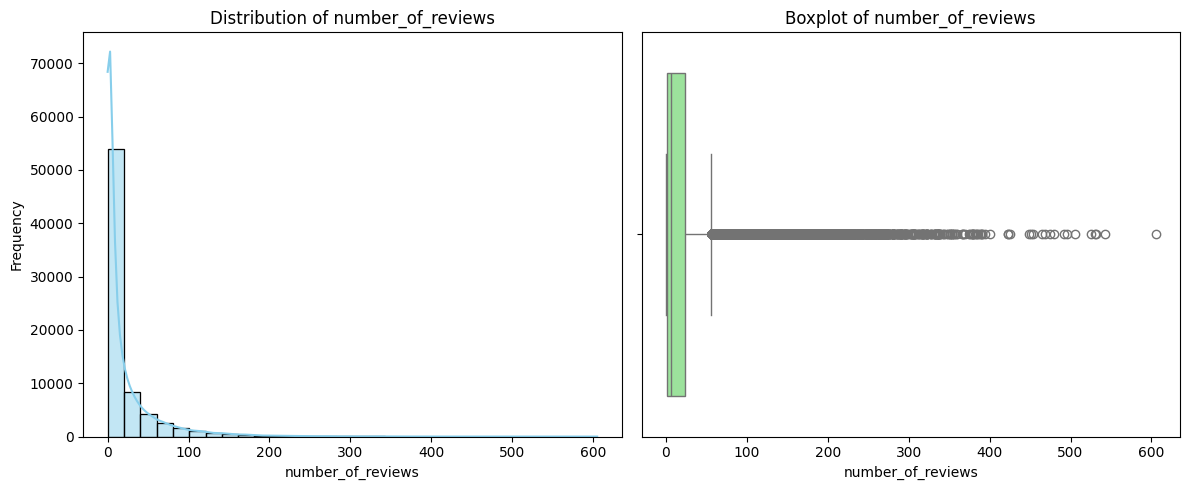

In [776]:
col = 'number_of_reviews'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Using log1p logarithmic transformation
## We don't use capping here because the values are very high, and it would affect the weightage in linear regression.
## Instead, we use log1p logarithmic transformation, to reduce the influence of large values in right-skewed data.
## It also safely handles zeros (since log(0) is undefined), compresses large values, and expands small values.

In [777]:
df['number_of_reviews_log1p'] = np.log1p(df['number_of_reviews'])

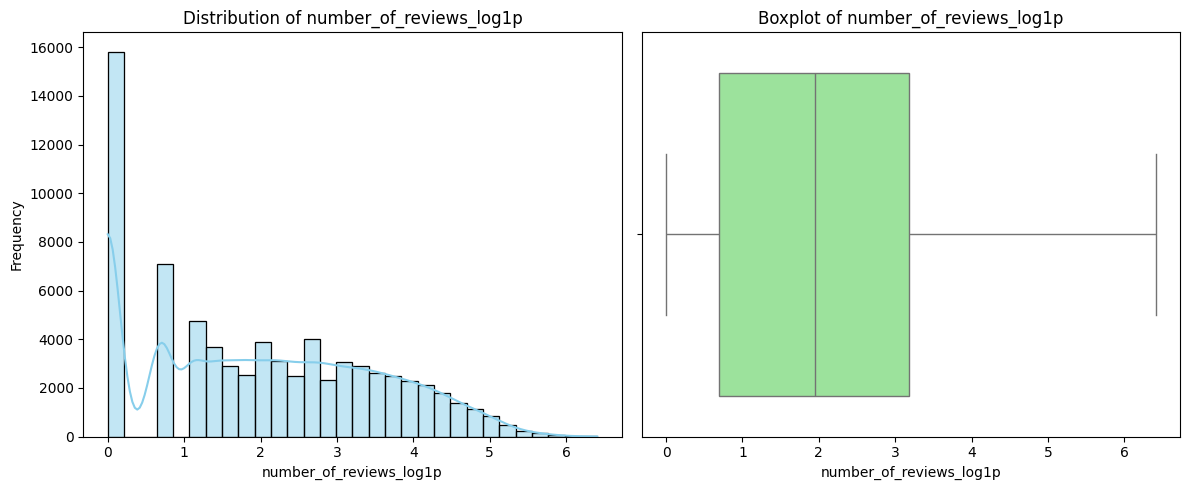

In [778]:
col = 'number_of_reviews_log1p'
# print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Drop original column
df.drop(columns=['number_of_reviews'], inplace=True)

# days_since_last_review distribution plot and reducing effect oh big values

Column 'days_since_last_review' unique values: [3373 2941 2950 ... 4142 4177 4306]


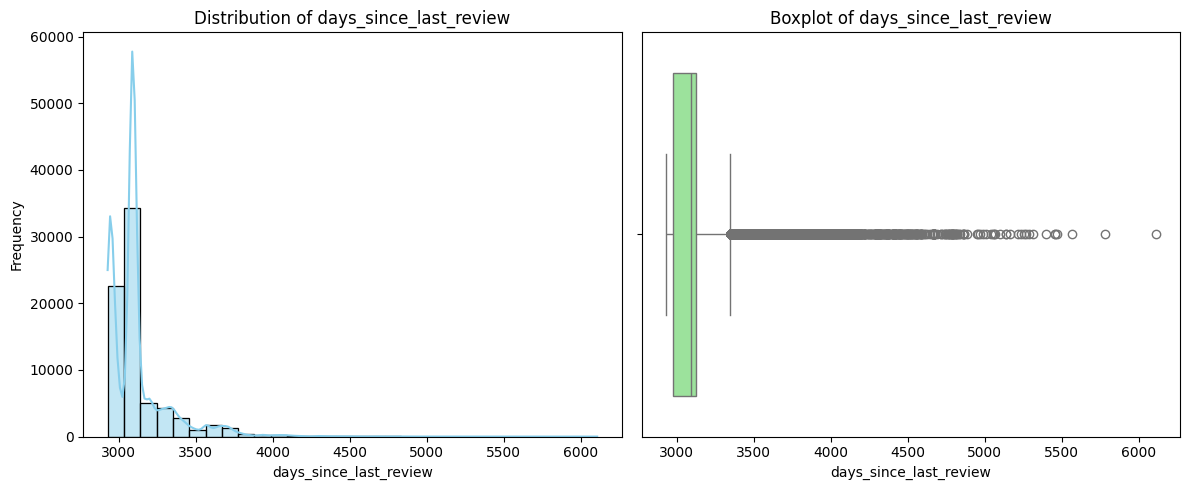

In [779]:
col = 'days_since_last_review'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

## Using Log1p logarithmic transformation, to reduce the influence of large values

In [780]:
df['days_since_last_review_log1p'] = np.log1p(df['days_since_last_review'])

Column 'days_since_last_review_log1p' unique values: [8.12385426 7.9868449  7.98989937 8.03592637 8.06652149 7.99294455
 8.03818918 8.041091   7.98650494 8.03980234 8.08764029 8.08671792
 8.03527891 8.04302089 8.09681747 8.06148687 8.07930819 7.98956045
 8.06117136 7.98718475 8.03689677 8.25997566 8.1241506  7.99125393
 8.11910084 7.99934295 8.0730912  8.03915739 8.08733293 8.04334217
 7.98514393 8.22469956 7.98888225 8.04044688 8.03883476 8.05006542
 8.08794755 7.99496952 7.98582467 8.19201691 8.03722003 8.23747929
 8.09894675 7.98378107 8.04654936 8.03495502 8.03560269 8.03851202
 8.07277933 8.2179782 ]


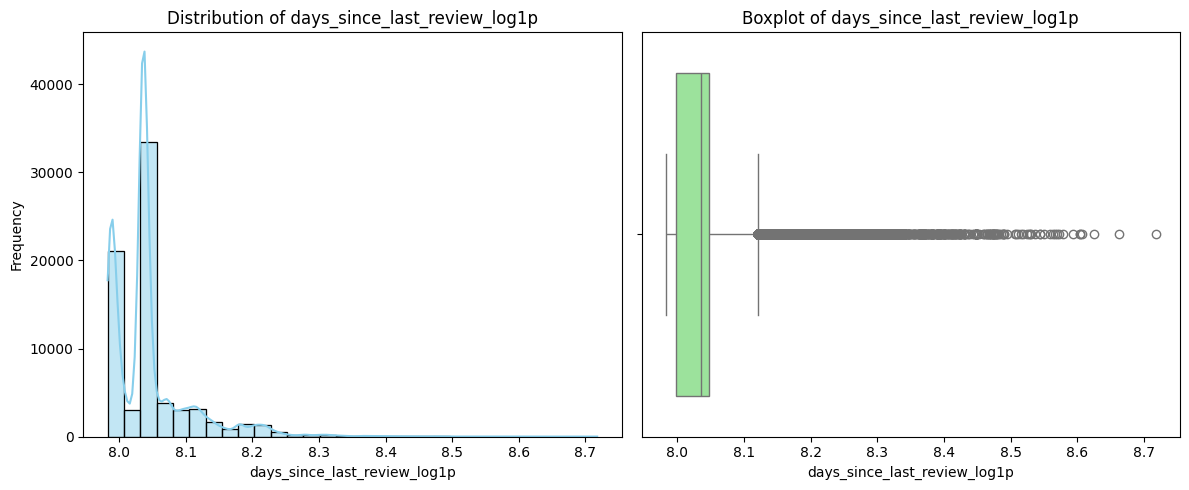

In [781]:
col = 'days_since_last_review_log1p'
print(f"Column '{col}' unique values:", df[col].unique()[:50])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Drop originla column
df.drop(columns=['days_since_last_review'], inplace=True)

# host_response_rate 16.94% outliers

Column 'host_response_rate' unique values: [100.  71.  68.  67.  83.  50.  90.  86.  92.  82.  80.  89.  93.  99.
   0.  88.  96.  70.  94.  91.  25.  95.  98.  62.  29.  33.  81.  63.
  38.  60.  79.  78.  75.  65.  97.  87.  40.  54.  53.  58.  76.  30.
  64.  17.  20.  77.  73.  41.  59.  57.  85.  56.  42.  44.  35.  14.
  74.  27.  10.  84.   6.  72.  36.  55.  43.  13.  39.  46.  26.  61.
  52.  23.  22.  69.  66.  15.  11.  31.  21.  47.]


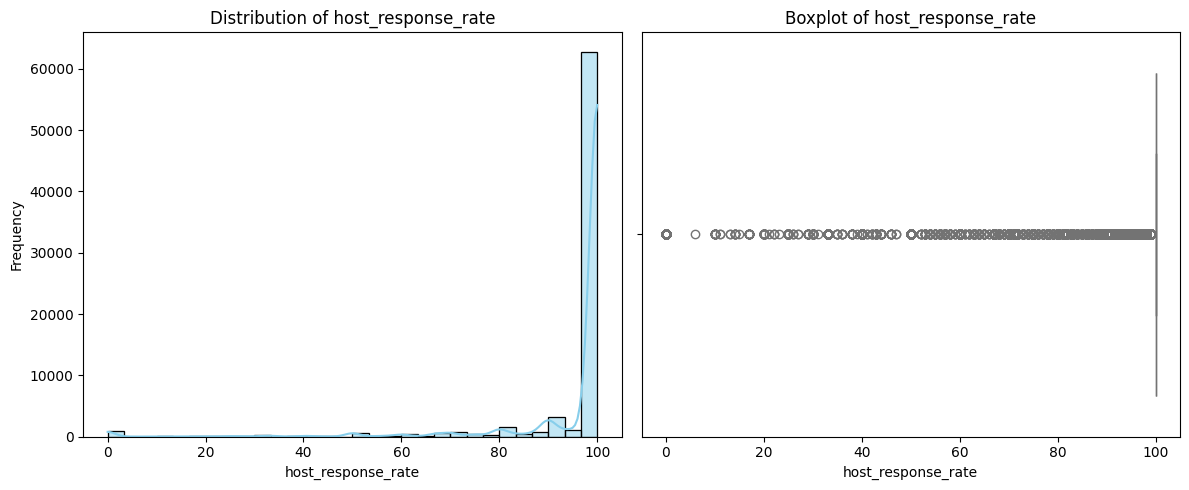

In [783]:
col = 'host_response_rate'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

df['host_response_rate_logged'] = np.log(df['host_response_rate'].max() + 1 - df['host_response_rate'])

col = 'host_response_rate_logged'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Drop originla column
df.drop(columns=['host_response_rate'], inplace=True)

# days_since_first_review distribution and handle outliers

Column 'days_since_first_review' unique values: [3403 2990 3087 ... 4737 5241 5429]


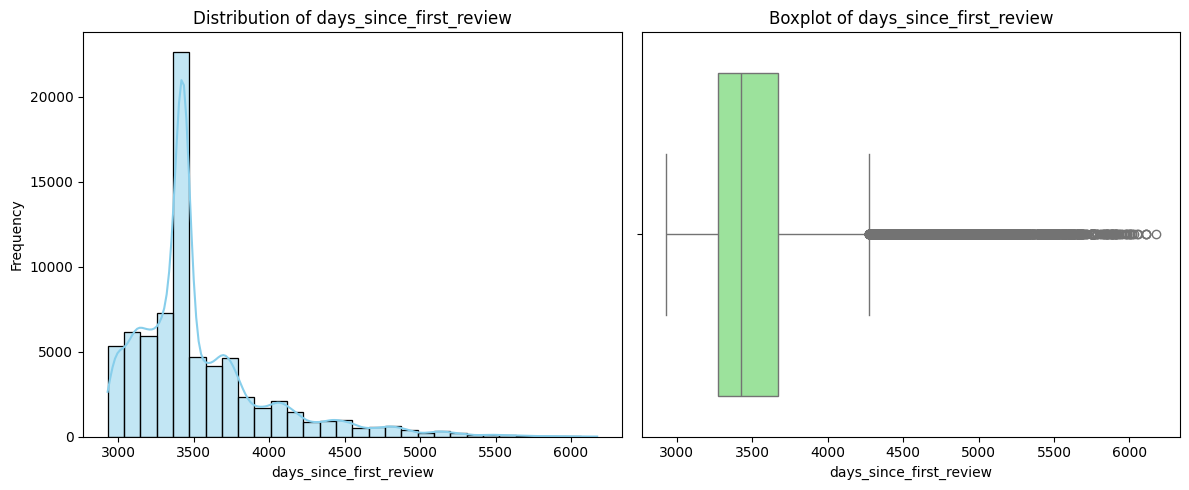

In [784]:
col = 'days_since_first_review'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# using logarithmic tranformation to reduce impact of high values

In [785]:
df['days_since_first_review_log1p'] = np.log1p(df['days_since_first_review'])

Column 'days_since_first_review_log1p' unique values: [8.13270649 8.00336306 8.03527891 ... 8.46337038 8.56445838 8.59969441]


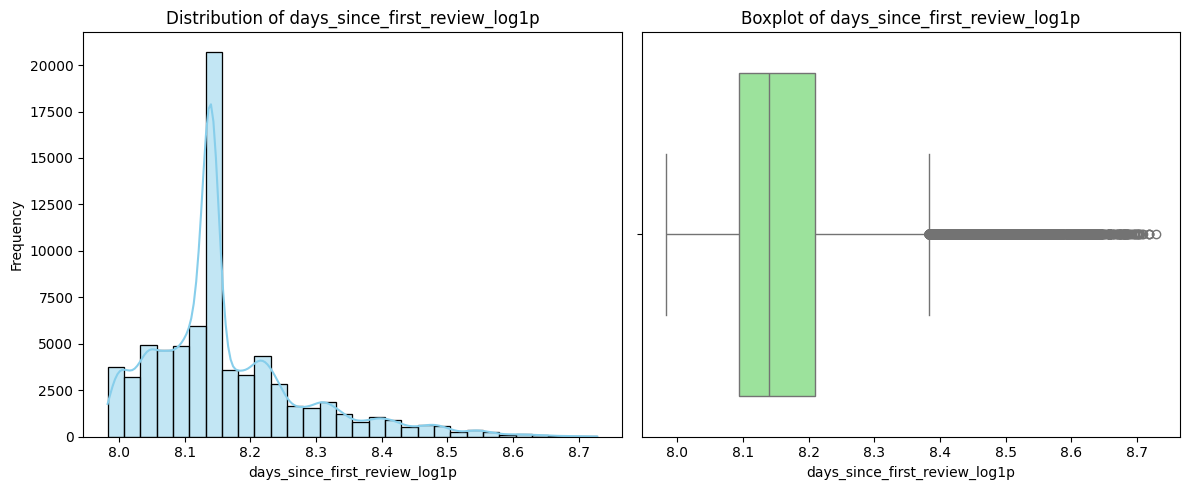

In [786]:
col = 'days_since_first_review_log1p'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Drop originla column
df.drop(columns=['days_since_first_review'], inplace=True)

# handling outlieers for host_days_since (0.25% outliers) and checking distribution

Column 'host_days_since' unique values: [4948 3037 3274 ... 6432 5644 5894]


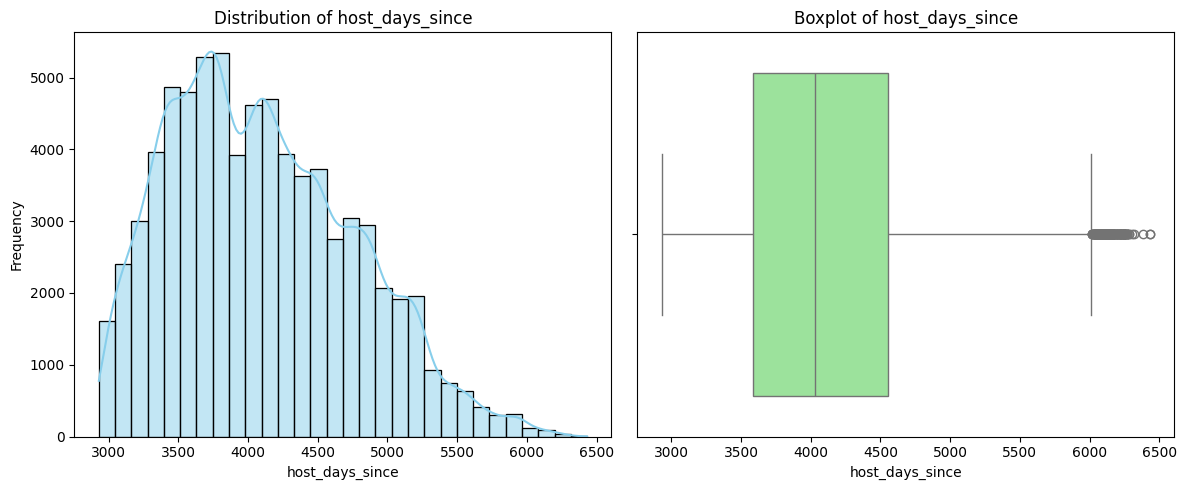

In [787]:
col = 'host_days_since'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

## using logarithmic transformation reducing the effect of high number values

In [788]:
df['host_days_since_log1p'] = np.log1p(df['host_days_since'])

Column 'host_days_since_log1p' unique values: [8.50694081 8.01895468 8.09407315 ... 8.76919627 8.63852548 8.68185981]


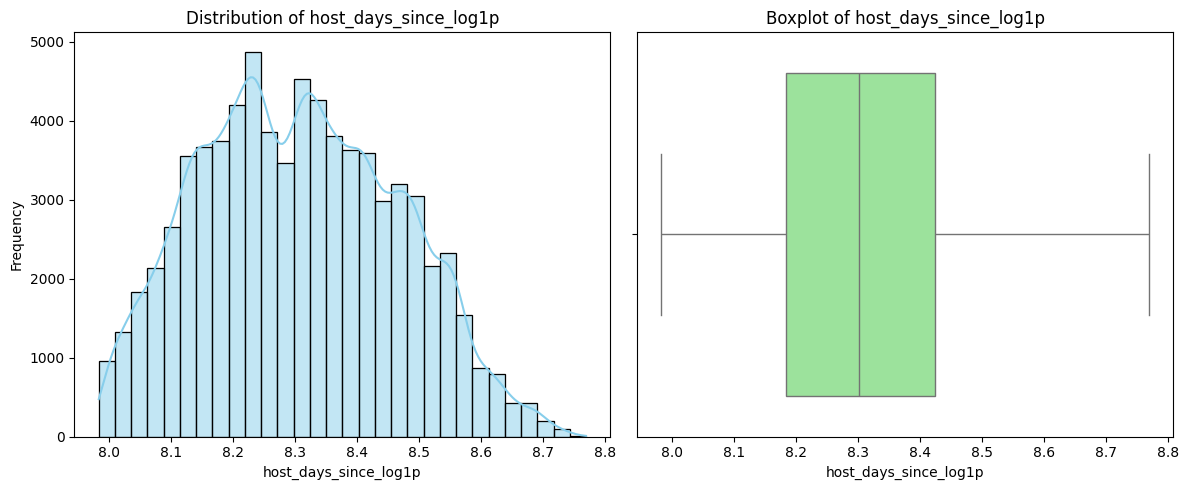

In [789]:
col = 'host_days_since_log1p'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Drop originla column
df.drop(columns=['host_days_since'], inplace=True)

# handlinmg outliers for beds having (7.67% outliers)

Column 'beds' unique values: [ 1.  3.  2.  7.  4.  6.  5. 10.  8. 16.  9. 13. 12. 11. 14. 15.  0. 18.]


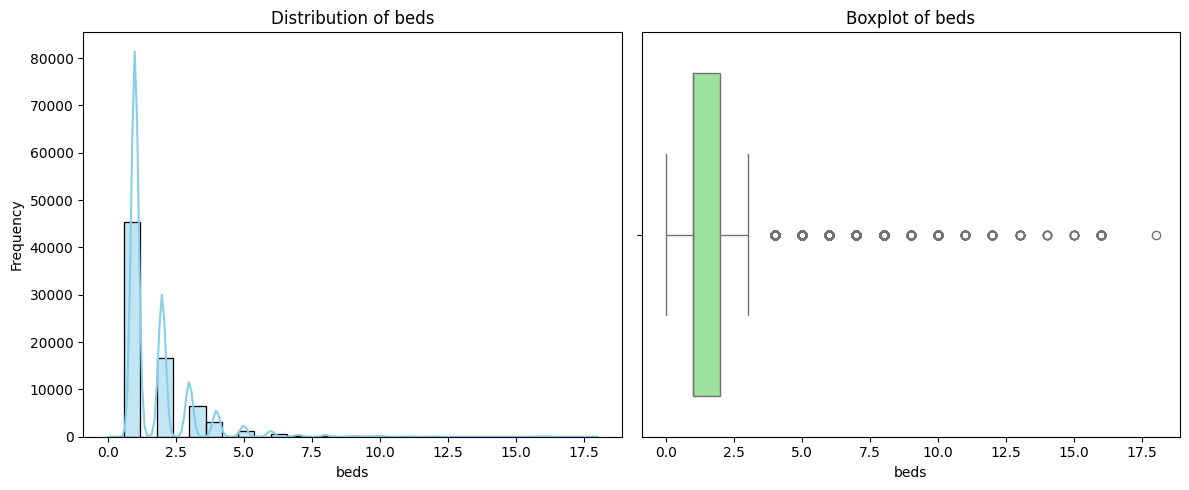

In [790]:
col = 'beds'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# capping 1% outliers and keeping the 99% data same to reduce impact of much higher values

In [791]:
upper_limit = df['beds'].quantile(0.99)
print("99th Percentile (Upper Limit):", upper_limit)

df['beds_capped'] = np.where(df['beds'] > upper_limit, upper_limit, df['beds'])

99th Percentile (Upper Limit): 6.0


Column 'beds_capped' unique values: [1. 3. 2. 6. 4. 5. 0.]


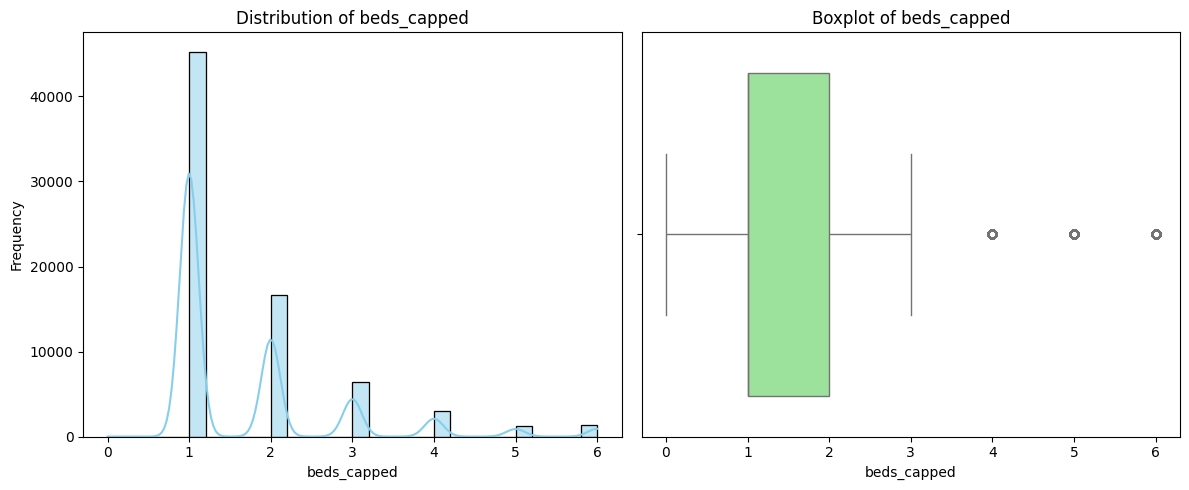

In [792]:
col = 'beds_capped'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Drop originla column
df.drop(columns=['beds'], inplace=True)

# accommodates columns handle outliers having (4.86% outliers)

Column 'accommodates' unique values: [ 3  7  5  4  2  6  8  1  9 10 16 11 12 14 13 15]


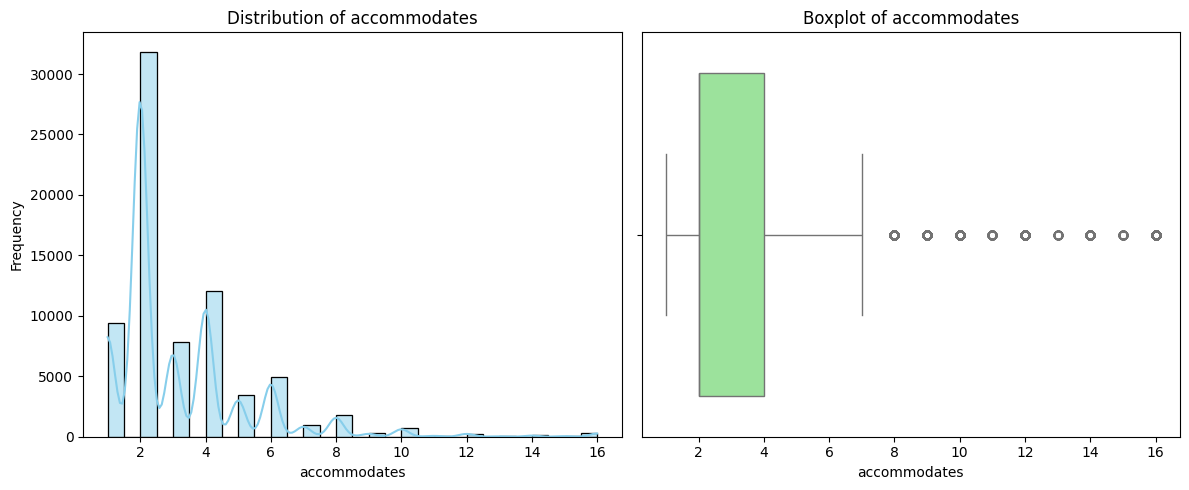

In [793]:
col = 'accommodates'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

## outliers on right side we will cap the top 1% for reduce the effect of outliers for linear regression model

In [794]:
upper_limit = df['accommodates'].quantile(0.99)
print("99th Percentile (Upper Limit):", upper_limit)

df['accommodates_capped'] = np.where(df['accommodates'] > upper_limit, upper_limit, df['accommodates'])

99th Percentile (Upper Limit): 12.0


Column 'accommodates_capped' unique values: [ 3.  7.  5.  4.  2.  6.  8.  1.  9. 10. 12. 11.]


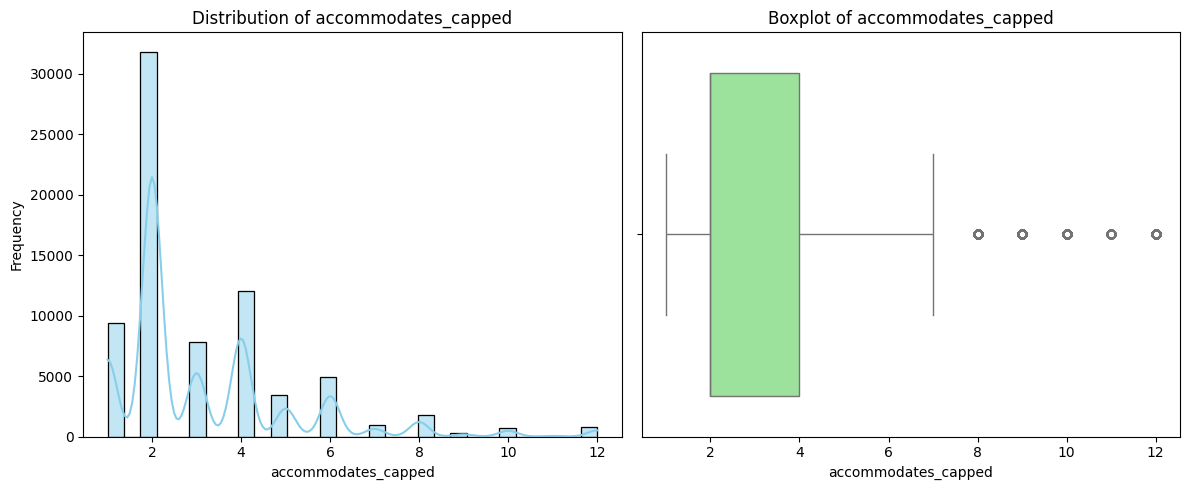

In [795]:
col = 'accommodates_capped'
print(f"Column '{col}' unique values:", df[col].unique())
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=df[col], color='lightgreen')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)

plt.tight_layout()
plt.show()

# Drop originla column
df.drop(columns=['accommodates'], inplace=True)

log_price                 :   2.07% outliers
accommodates              :   4.86% outliers done
bathrooms                 :  21.34% outliers done
host_has_profile_pic      :   0.30% outliers
host_identity_verified    :   0.00% outliers
host_response_rate        :  16.94% outliers done
latitude                  :   0.00% outliers
longitude                 :   0.00% outliers
number_of_reviews         :  11.07% outliers done
review_scores_rating      :   6.24% outliers
zipcode                   :   0.00% outliers
bedrooms                  :  32.70% outliers done
beds                      :   7.67% outliers done
amenities_count           :   1.84% outliers
host_days_since           :   0.25% outliers done
days_since_first_review   :   7.40% outliers done
days_since_last_review    :  10.84% outliers done

In [796]:
cols = df.columns.tolist()
print("cols_name:", cols)
print("--"*50)
for col in cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()} | Unique Count: {df[col].nunique()}")
    print("Unique Values:", df[col].unique()[:100])
    print("-" * 80)

cols_name: ['log_price', 'property_type', 'room_type', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'instant_bookable', 'latitude', 'longitude', 'neighbourhood', 'review_scores_rating', 'zipcode', 'amenities_count', 'bedrooms_cat_1.0', 'bedrooms_cat_2.0', 'bedrooms_cat_3.0', 'bedrooms_cat_4.0', 'bathrooms_cat_0.5', 'bathrooms_cat_1.0', 'bathrooms_cat_1.5', 'bathrooms_cat_2.0', 'bathrooms_cat_2.5', 'bathrooms_cat_3.0', 'bathrooms_cat_3.5', 'number_of_reviews_log1p', 'days_since_last_review_log1p', 'days_since_first_review_log1p', 'host_days_since_log1p', 'beds_capped', 'accommodates_capped']
----------------------------------------------------------------------------------------------------
log_price | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 767
Unique Values: [5.01063529 5.12989872 4.97673374 6.62007321 4.74493213 4.44265126
 4.41884061 4.78749174 3.58351894 4.60517019 4.24849524 5.29

# Heatmap to see correlation which column effect most the target variable

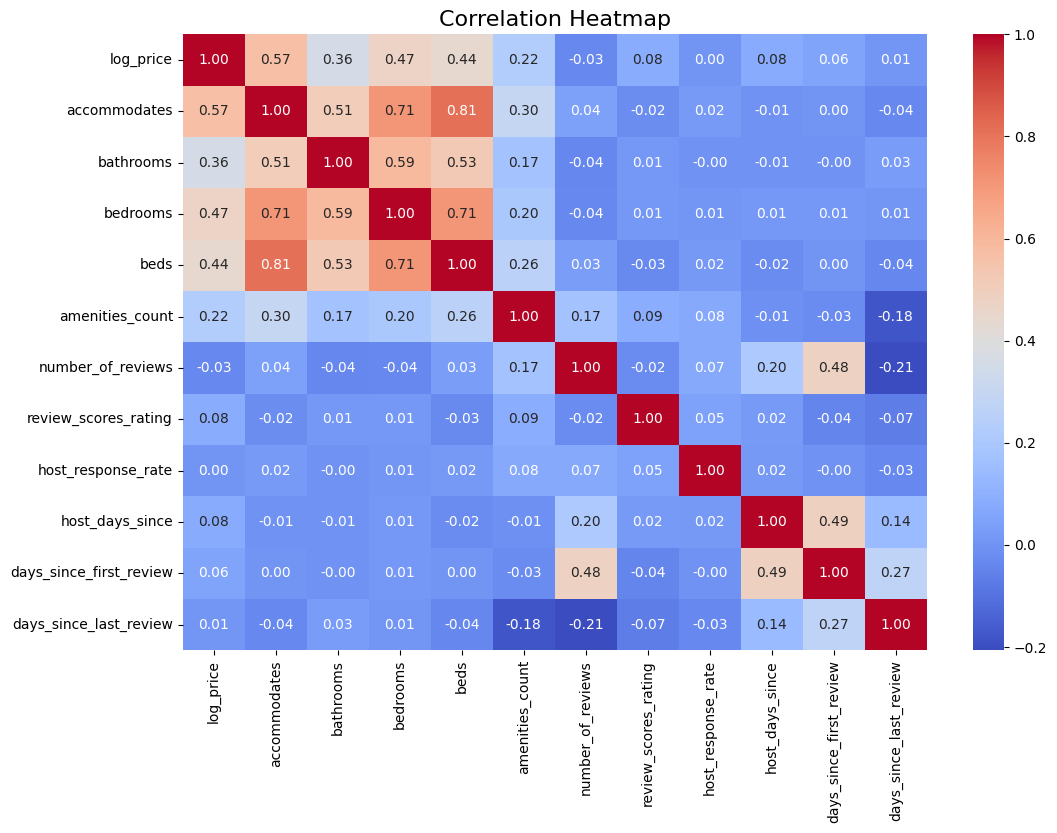

In [832]:
num_cols = [
    'log_price','accommodates','bathrooms','bedrooms','beds','amenities_count','number_of_reviews',
    'review_scores_rating','host_response_rate','host_days_since','days_since_first_review','days_since_last_review']

corr = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# 'Accommodates' has the strongest correlation with 'log_price' (0.57), meaning that as the number of accommodates increases, the price also tends to increase at a moderate level.

# 'Bedrooms' and 'Beds' have moderate correlations with 'log_price' (0.47 and 0.44, respectively), indicating that they also increase with price but have less impact than 'Accommodates'.

# The remaining columns are not highly correlated with 'log_price'.

# Applying Label Encoding for columns having category and ordered values like in cancellation_policy and t/f => 1/0

In [797]:
from sklearn.preprocessing import LabelEncoder

# Selects Categorical columns
label_cols = ['cancellation_policy','instant_bookable','host_has_profile_pic','host_identity_verified','cleaning_fee']

le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [798]:
cols = df.columns.tolist()
print("cols_name:", cols)
print("--"*50)
for col in cols:
    print(f"{col} | Type: {df[col].dtype} | Nulls: {df[col].isnull().sum()} | Filled: {df[col].notnull().sum()} | Unique Count: {df[col].nunique()}")
    print("Unique Values:", df[col].unique()[:10])
    print("-" * 80)

cols_name: ['log_price', 'property_type', 'room_type', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'instant_bookable', 'latitude', 'longitude', 'neighbourhood', 'review_scores_rating', 'zipcode', 'amenities_count', 'bedrooms_cat_1.0', 'bedrooms_cat_2.0', 'bedrooms_cat_3.0', 'bedrooms_cat_4.0', 'bathrooms_cat_0.5', 'bathrooms_cat_1.0', 'bathrooms_cat_1.5', 'bathrooms_cat_2.0', 'bathrooms_cat_2.5', 'bathrooms_cat_3.0', 'bathrooms_cat_3.5', 'number_of_reviews_log1p', 'days_since_last_review_log1p', 'days_since_first_review_log1p', 'host_days_since_log1p', 'beds_capped', 'accommodates_capped']
----------------------------------------------------------------------------------------------------
log_price | Type: float64 | Nulls: 0 | Filled: 74111 | Unique Count: 767
Unique Values: [5.01063529 5.12989872 4.97673374 6.62007321 4.74493213 4.44265126
 4.41884061 4.78749174 3.58351894 4.60517019]
--------------

# Applying One-Hot Encode for nominal — no natural order, multiple categories.

In [799]:
onehot_cols = ['property_type','room_type','bed_type','city']
df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

# Target encoding for zipcode and neigborhood sicne they contains 600+ unique values
# zipcode is nemeric but actually categorical data so it will be good for targeting encoding 

In [800]:
for col in ['neighbourhood', 'zipcode']:
    target_mean = df.groupby(col)['log_price'].mean()
    df[col+'_encoded'] = df[col].map(target_mean)
    
    # Drop original column
    df.drop(col, axis=1, inplace=True)

In [801]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 75 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   log_price                         74111 non-null  float64
 1   cancellation_policy               74111 non-null  int64  
 2   cleaning_fee                      74111 non-null  int64  
 3   host_has_profile_pic              74111 non-null  int64  
 4   host_identity_verified            74111 non-null  int64  
 5   host_response_rate                74111 non-null  float64
 6   instant_bookable                  74111 non-null  int64  
 7   latitude                          74111 non-null  float64
 8   longitude                         74111 non-null  float64
 9   review_scores_rating              74111 non-null  float64
 10  amenities_count                   74111 non-null  int64  
 11  bedrooms_cat_1.0                  74111 non-null  bool   
 12  bedr

# make variables for model train

In [802]:
X = df.drop(columns=['log_price'])
y = df['log_price']

# Standard Scaling for numeric columns only not for encoded columns 

In [803]:
num_cols = ['latitude', 'longitude', 'review_scores_rating', 'amenities_count',
            'number_of_reviews_log1p', 'days_since_last_review_log1p',
            'host_response_rate', 'days_since_first_review_log1p',
            'host_days_since_log1p', 'beds_capped', 'accommodates_capped']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Data Splitting for training and test data

In [804]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the model and making prediction for test data to check accuracy of our data

In [805]:
my_lr = LinearRegression()
my_lr.fit(X_train_scaled, y_train)
y_pred = my_lr.predict(X_test_scaled)

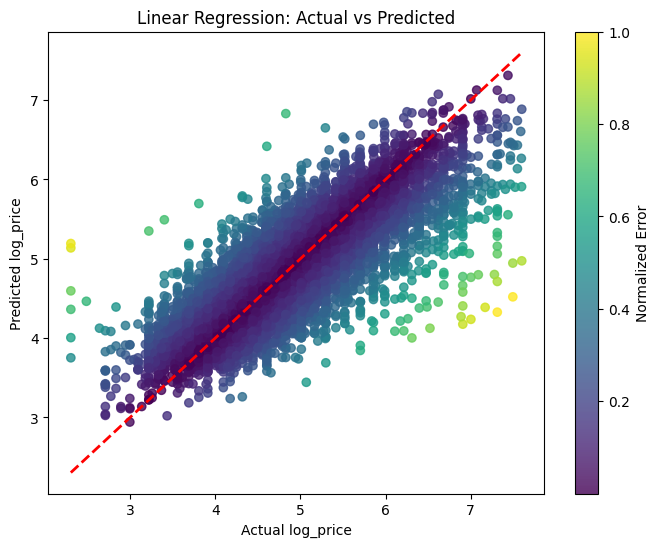

In [806]:
errors = np.abs(y_test - y_pred)
colors = errors / errors.max() 

plt.figure(figsize=(8,6))
scatter = plt.scatter(y_test, y_pred, c=colors, cmap='viridis', alpha=0.8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) #draws perfet line linear regression
plt.xlabel('Actual log_price')
plt.ylabel('Predicted log_price')
plt.title('Linear Regression: Actual vs Predicted')
plt.colorbar(scatter, label='Normalized Error')  # shows colors scale
plt.show()

In [858]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print(f"MAE: {mae:.4f}")
print(f"R^2: {r2:.4f}")

Linear Regression Performance:
MAE: 0.2699
R^2: 0.7288


# Conclusion 
## we get R^2 as 0.6699 means 66% of accurate prediction 

# Now We will try another algorith that's XGBoost algorithm, which is robust to outliers because it is a tree-based method. It improves its accuracy each time a new tree is added, making the predictions progressively better.

## Import xgboost (Extreme Gradient Boosting)

In [837]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# create model
### n_estimators: How many trees to be made
### max_depth: max depth of an each tree
### learning_rate: controls the step size for updating predictions from each tree 
### subsample: how much data should be use for training the each tree
### colsample_bytree: the features each tree uses 0.8 as 80% 

In [875]:
xgb_model = xgb.XGBRegressor(
    n_estimators=800,      # number of trees
    max_depth=7,           # depth of each tree
    learning_rate=0.05,    # step size shrinkage
    subsample=0.8,         # use 80% of data per tree
    colsample_bytree=0.85,  # use 80% features per tree
    random_state=42
)

## Train the model

In [876]:
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.85
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Make Prediction and evaluate the results

In [877]:
y_pred = xgb_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R^2 Score:", r2)

RMSE: 0.3701831703050124
R^2 Score: 0.7332515647765592


## Tree-based model gives R² = 0.733, higher than linear regression R² = 0.669.
## Trees are robust to outliers, so predictions are less affected by extreme values.
## Linear regression is sensitive to outliers, which can reduce its accuracy.
## Hence, tree model performs better on this dataset.

In [872]:
n_estimators_list = [400, 500, 600]
max_depth_list = [4, 6, 8]
learning_rate_list = [0.01, 0.05, 0.1]
subsample_list = [0.7, 0.8, 1.0]
colsample_bytree_list = [0.7, 0.8, 1.0]

best_r2 = -1
best_params = {}

for n in n_estimators_list:
    for depth in max_depth_list:
        for lr in learning_rate_list:
            for subsample in subsample_list:
                for colsample in colsample_bytree_list:
                    model = xgbXGBRegressor(
                        n_estimators=n,
                        max_depth=depth,
                        learning_rate=lr,
                        subsample=subsample,
                        colsample_bytree=colsample,
                        random_state=42
                    )
                    model.fit(X_train, y_train)
                    preds = model.predict(X_test)
                    r2 = r2_score(y_test, preds)
                    
                    if r2 > best_r2:
                        best_r2 = r2
                        best_params = {
                            'n_estimators': n,
                            'max_depth': depth,
                            'learning_rate': lr,
                            'subsample': subsample,
                            'colsample_bytree': colsample
                        }

print("Best R²:", best_r2)
print("Best Parameters:", best_params)

Best R²: 0.7324689816725226
Best Parameters: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}


In [874]:
n_estimators_list = [600, 700, 800]
max_depth_list = [5, 6, 7]
learning_rate_list = [0.03, 0.05, 0.07]
subsample_list = [0.75, 0.8, 0.85]
colsample_bytree_list = [0.75, 0.8, 0.85]

best_r2 = -1
best_params = {}

for n in n_estimators_list:
    for depth in max_depth_list:
        for lr in learning_rate_list:
            for subsample in subsample_list:
                for colsample in colsample_bytree_list:
                    model = xgb.XGBRegressor(
                        n_estimators=n,
                        max_depth=depth,
                        learning_rate=lr,
                        subsample=subsample,
                        colsample_bytree=colsample,
                        random_state=42
                    )
                    model.fit(X_train, y_train)
                    preds = model.predict(X_test)
                    r2 = r2_score(y_test, preds)
                    
                    if r2 > best_r2:
                        best_r2 = r2
                        best_params = {
                            'n_estimators': n,
                            'max_depth': depth,
                            'learning_rate': lr,
                            'subsample': subsample,
                            'colsample_bytree': colsample
                        }

print("Best R²:", best_r2)
print("Best Parameters:", best_params)

Best R²: 0.7332515647765592
Best Parameters: {'n_estimators': 800, 'max_depth': 7, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.85}
